In [1]:
# Week 1: Install Dependencies
!pip install kagglehub pycocotools albumentations torch torchvision torchaudio torchmetrics segmentation-models-pytorch scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 18.9 MB/s eta 0:00:00


In [2]:
# Week 1: Dataset Acquisition
import kagglehub
import os

# Download COCO 2017
path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")
print("Dataset path:", path)

# Paths
train_img_dir = os.path.join(path, "coco2017", "train2017")
ann_file = os.path.join(path, "coco2017", "annotations", "instances_train2017.json")

Using Colab cache for faster access to the 'coco-2017-dataset' dataset.
Dataset path: /kaggle/input/coco-2017-dataset


loading annotations into memory...
Done (t=22.17s)
creating index...
index created!
Number of images: 118287
Number of categories: 80
Categories: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'tooth

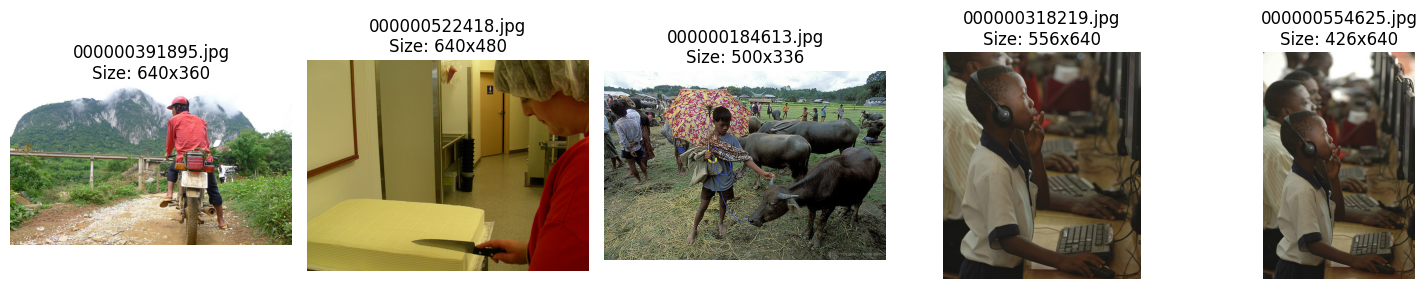

In [3]:
# Week 1: Load and Inspect Dataset (Explore structure, images)
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Load annotations
coco = COCO(ann_file)

print("Number of images:", len(coco.imgs))
print("Number of categories:", len(coco.cats))
print("Categories:", [cat['name'] for cat in coco.cats.values()])

# Sample 5 images
img_ids = coco.getImgIds()[:5]

fig, axs = plt.subplots(1, 5, figsize=(15, 3))
for i, img_id in enumerate(img_ids):
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(train_img_dir, img_info['file_name'])
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    axs[i].imshow(image)
    axs[i].set_title(f"{img_info['file_name']}\nSize: {img_info['width']}x{img_info['height']}")
    axs[i].axis("off")
plt.tight_layout()
plt.show()  # Screenshot: Sample images

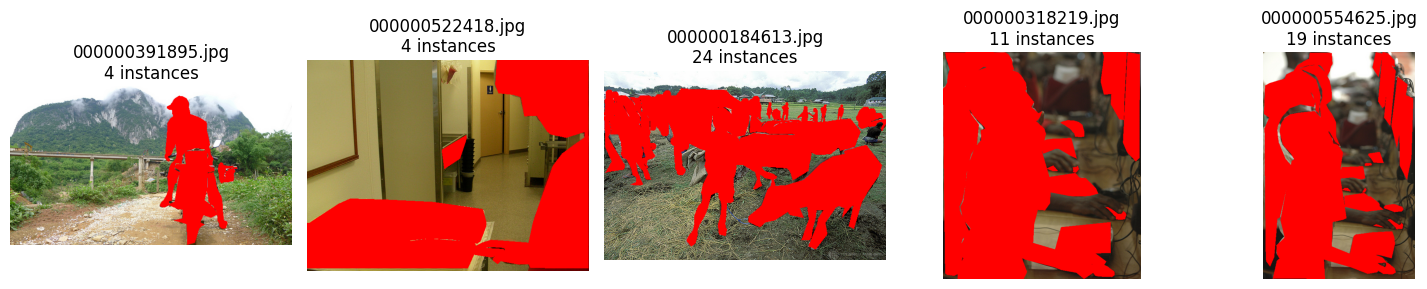

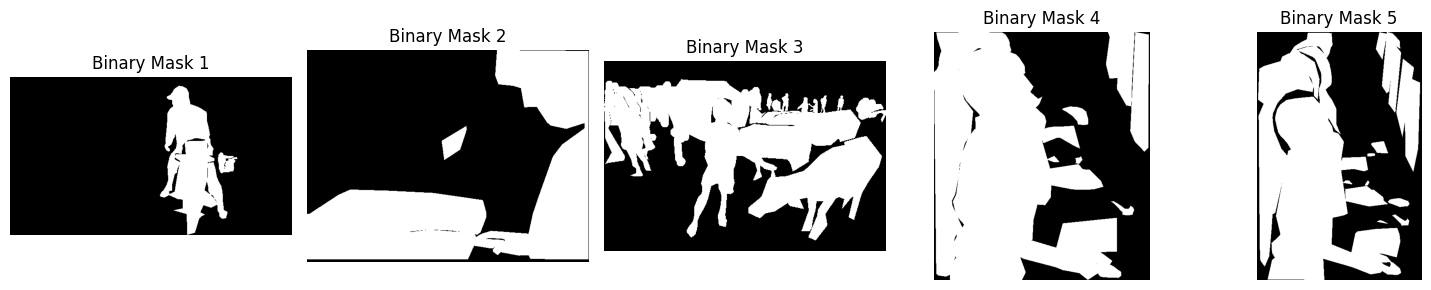

In [4]:
# Week 1: Explore Masks (View example masks; convert multi-class to binary)
# Binary: Union all instances as 'main subject'

fig, axs = plt.subplots(1, 5, figsize=(15, 3))
for i, img_id in enumerate(img_ids):
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(train_img_dir, img_info['file_name'])
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)
    masks = [coco.annToMask(ann) for ann in anns]
    binary_mask = np.logical_or.reduce(masks) if masks else np.zeros((h, w), dtype=bool)

    overlay = image.copy()
    overlay[binary_mask] = [255, 0, 0]

    axs[i].imshow(overlay)
    axs[i].set_title(f"{img_info['file_name']}\n{len(anns)} instances")
    axs[i].axis("off")
plt.tight_layout()
plt.show()  # Screenshot: Images with mask overlays

# Binary masks
fig, axs = plt.subplots(1, 5, figsize=(15, 3))
for i, img_id in enumerate(img_ids):
    img_info = coco.loadImgs(img_id)[0]
    h, w = img_info['height'], img_info['width']
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)
    masks = [coco.annToMask(ann) for ann in anns]
    binary_mask = np.logical_or.reduce(masks) if masks else np.zeros((h, w), dtype=bool)

    axs[i].imshow(binary_mask, cmap='gray')
    axs[i].set_title(f"Binary Mask {i+1}")
    axs[i].axis("off")
plt.tight_layout()
plt.show()  # Screenshot: Binary masks

## Milestone 1: Week 2 - Data Preprocessing and Validation

- Pipeline: Resize (256x256), Normalize, Augment (flip, brightness).
- Alignment: Match image/mask dims.
- Binary: Union instances.
- Split: 80/20 on 3000 images.

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import cv2
import numpy as np
import os

# Train Pipeline (256x256)
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# Val Pipeline
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# Dataset Class
class COCOSubjectDataset(Dataset):
    def __init__(self, coco, img_dir, img_ids, transform=None):
        self.coco = coco
        self.img_dir = img_dir
        self.img_ids = img_ids
        self.transform = transform

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        masks = [self.coco.annToMask(ann) for ann in anns]

        # Convert binary mask to uint8 after logical_or.reduce
        mask = (np.logical_or.reduce(masks)).astype(np.uint8) if masks else np.zeros((h, w), dtype=np.uint8)

        if mask.shape != (h, w):
            
            mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask'].long()

        return image, mask

# 3000 images subset
all_img_ids = coco.getImgIds()[:3000]
train_ids, val_ids = train_test_split(all_img_ids, test_size=0.2, random_state=42)

train_ds = COCOSubjectDataset(coco, train_img_dir, train_ids, train_transform)
val_ds = COCOSubjectDataset(coco, train_img_dir, val_ids, val_transform)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

# Test sample
img, msk = train_ds[0]
print("Image shape:", img.shape, "Mask shape:", msk.shape, "Mask unique:", torch.unique(msk))

Train: 2400, Val: 600
Image shape: torch.Size([3, 256, 256]) Mask shape: torch.Size([256, 256]) Mask unique: tensor([0, 1])


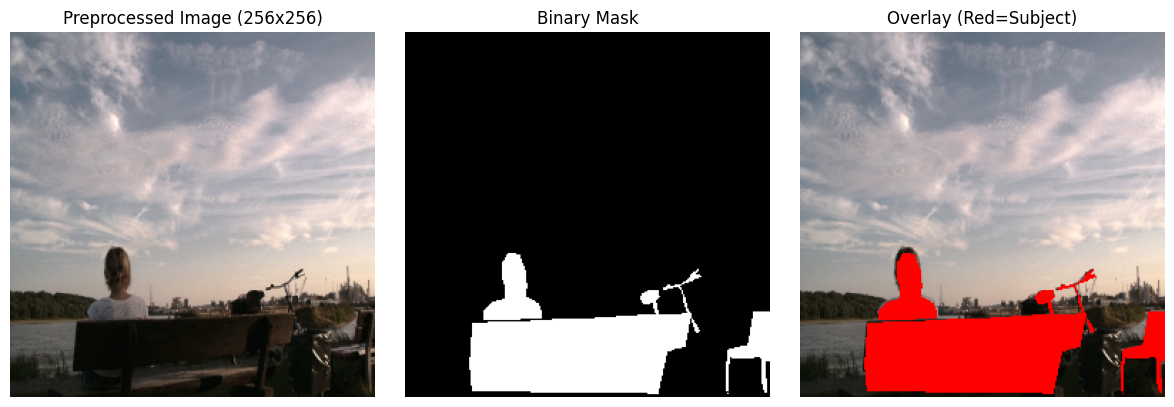

In [11]:
def denorm(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(img_tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(img_tensor.device)
    return img_tensor * std + mean

img, msk = next(iter(train_loader))
img_vis = denorm(img[0]).permute(1,2,0).numpy().clip(0,1)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(img_vis)
axs[0].set_title("Preprocessed Image (256x256)")
axs[1].imshow(msk[0].numpy(), cmap='gray')
axs[1].set_title("Binary Mask")
overlay = img_vis.copy()
overlay[msk[0].numpy() == 1] = [1, 0, 0]
axs[2].imshow(overlay)
axs[2].set_title("Overlay (Red=Subject)")
for ax in axs: ax.axis('off')
plt.tight_layout()
plt.show()  # Screenshot: Preprocessed sample

## Milestone 2: Week 3 - Initial Model Training

- Implement U-Net.
- Train on processed data, monitor metrics.
- Visualize early predictions.

In [8]:
# Week 3: Model Setup
import torch.nn as nn
from segmentation_models_pytorch import Unet
from segmentation_models_pytorch.losses import DiceLoss
from torchmetrics import JaccardIndex
import torch.optim as optim
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = Unet(encoder_name='resnet34', encoder_weights='imagenet', in_channels=3, classes=1, activation='sigmoid')
model.to(device)

criterion = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss(mode='binary')
optimizer = optim.Adam(model.parameters(), lr=1e-4)
iou_metric = JaccardIndex(task='binary').to(device)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch 1 Val: 100%|██████████| 75/75 [00:17<00:00,  4.18it/s, iou=0.758]


Epoch 1/5 - Train Loss: 1.3047, Val IoU: 0.5971


Epoch 2 Val: 100%|██████████| 75/75 [00:09<00:00,  7.91it/s, iou=0.807]


Epoch 2/5 - Train Loss: 1.2330, Val IoU: 0.5882


Epoch 3 Val: 100%|██████████| 75/75 [00:08<00:00,  8.52it/s, iou=0.825]


Epoch 3/5 - Train Loss: 1.2116, Val IoU: 0.6048


Epoch 4 Val: 100%|██████████| 75/75 [00:09<00:00,  8.17it/s, iou=0.814]


Epoch 4/5 - Train Loss: 1.2003, Val IoU: 0.6241


Epoch 5 Val: 100%|██████████| 75/75 [00:09<00:00,  7.82it/s, iou=0.751]


Epoch 5/5 - Train Loss: 1.1949, Val IoU: 0.6269


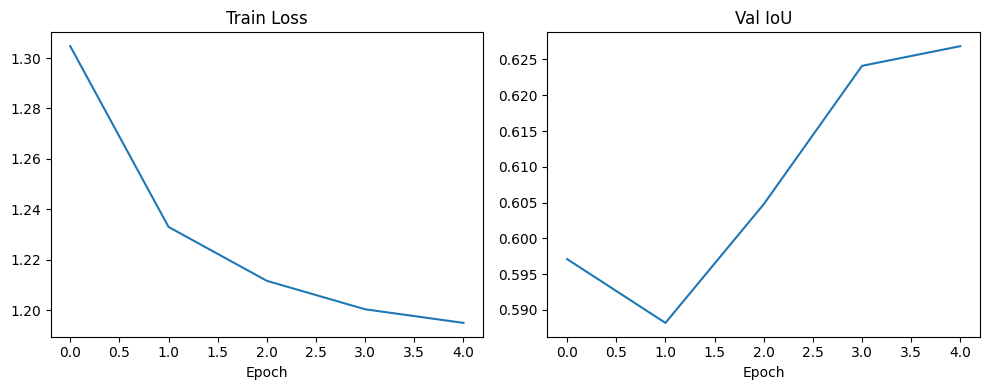

In [9]:
# Week 3: Training Loop (5 epochs with progress)
num_epochs = 5
train_losses, val_ious = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} Train", total=len(train_loader))
    for imgs, masks in train_pbar:
        imgs, masks = imgs.to(device), masks.float().to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds.squeeze(1), masks.squeeze(1)) + dice_loss(preds, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        train_pbar.set_postfix(loss=loss.item())
    train_losses.append(running_loss / len(train_loader))

    model.eval()
    iou_score = 0.0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1} Val", total=len(val_loader))
    with torch.no_grad():
        for imgs, masks in val_pbar:
            imgs, masks = imgs.to(device), masks.float().to(device)
            preds = model(imgs)
            iou = iou_metric(preds.squeeze(1) > 0.5, masks.squeeze(1)).item()
            iou_score += iou
            val_pbar.set_postfix(iou=iou)
    val_ious.append(iou_score / len(val_loader))

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_losses[-1]:.4f}, Val IoU: {val_ious[-1]:.4f}")

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(train_losses); plt.title('Train Loss'); plt.xlabel('Epoch')
plt.subplot(1,2,2); plt.plot(val_ious); plt.title('Val IoU'); plt.xlabel('Epoch')
plt.tight_layout()
plt.show()  # Screenshot: Training curves

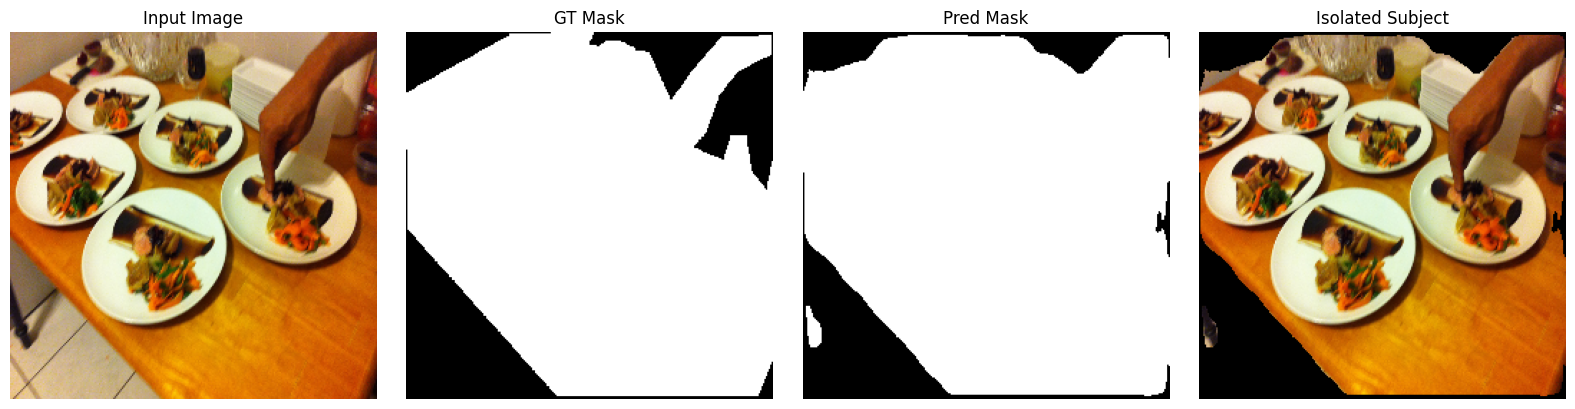

In [12]:
# Week 3: Visualize Early Predictions
model.eval()
with torch.no_grad():
    imgs, masks = next(iter(val_loader))
    imgs, masks = imgs.to(device), masks.to(device)
    preds = model(imgs)
    pred_masks = (preds > 0.5).float().squeeze(1)

img_vis = denorm(imgs[0]).permute(1,2,0).cpu().numpy().clip(0,1)
gt_mask = masks[0].squeeze().cpu().numpy()
pred_mask = pred_masks[0].cpu().numpy()

isolated = img_vis.copy()
isolated[pred_mask == 0] = 0

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(img_vis); axs[0].set_title("Input Image")
axs[1].imshow(gt_mask, cmap='gray'); axs[1].set_title("GT Mask")
axs[2].imshow(pred_mask, cmap='gray'); axs[2].set_title("Pred Mask")
axs[3].imshow(isolated); axs[3].set_title("Isolated Subject")
for ax in axs: ax.axis('off')
plt.tight_layout()
plt.show()  # Screenshot: Early predictions

## Milestone 2: Week 4 - Predictions and Fine-Tuning

- Val predictions vs. GT.
- Metrics (IoU/Dice).
- Fine-tune: Add rotation aug, lower LR, retrain 3 epochs.

Val Mean IoU: 0.6269, Dice: 0.7639


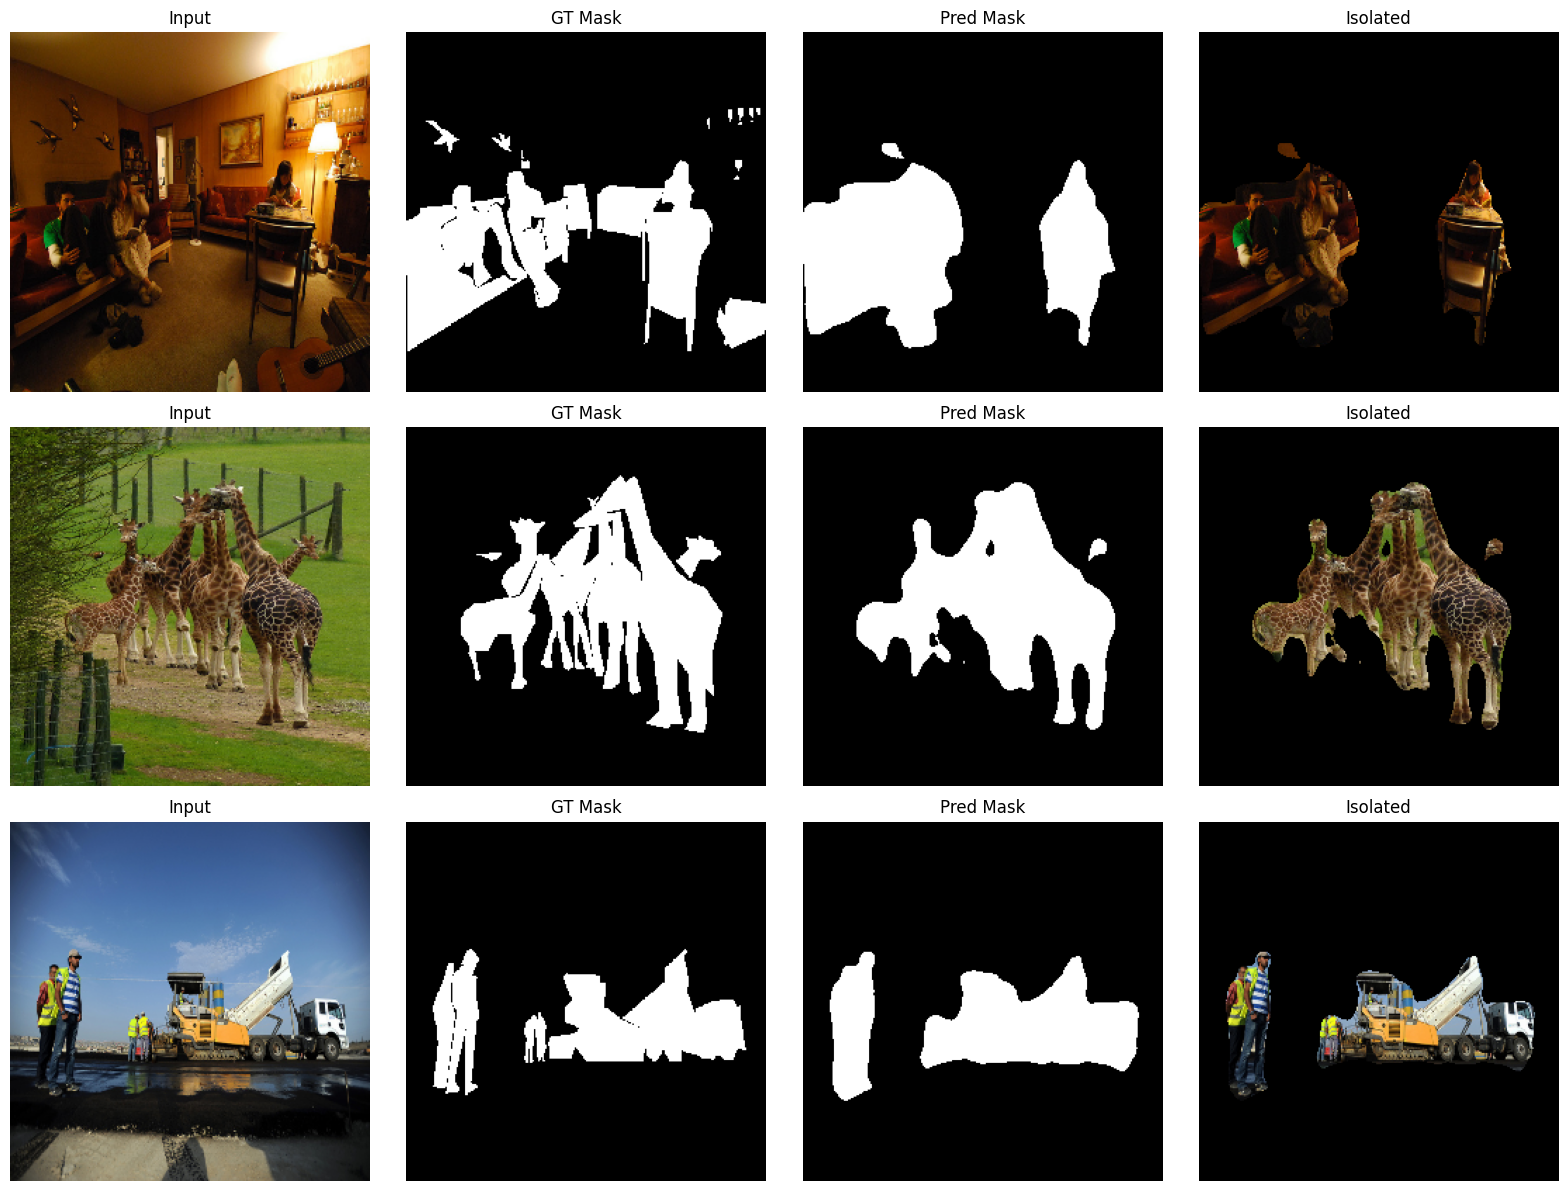

In [ ]:
# Week 4: Val Predictions & Metrics
import torchmetrics.functional as F 
import random
import numpy as np



model.eval()
all_ious, all_dices = [], []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.float().to(device)
        preds = model(imgs)
        pred_bins = (preds > 0.5).float().squeeze(1)
        all_ious.append(iou_metric(pred_bins, masks.squeeze(1)).item())
        # Calculate dice using functional API (F1-score is equivalent to Dice for binary)
        all_dices.append(F.f1_score(pred_bins.long(), masks.squeeze(1).long(), task='binary').item())

mean_iou = np.mean(all_ious)
mean_dice = np.mean(all_dices)
print(f"Val Mean IoU: {mean_iou:.4f}, Dice: {mean_dice:.4f}")

# 3 Sample Outputs
samples = [val_ds[i] for i in random.sample(range(len(val_ds)), 3)]
fig, axs = plt.subplots(3, 4, figsize=(16, 12))
for j, (img, gt) in enumerate(samples):
    img_tensor = denorm(img.unsqueeze(0).to(device)).squeeze().permute(1,2,0).cpu().numpy().clip(0,1)

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
    pred_mask = (pred > 0.5).float().squeeze().cpu().numpy()

    isolated = img_tensor.copy()
    isolated[pred_mask == 0] = 0

    axs[j,0].imshow(img_tensor); axs[j,0].set_title("Input")
    axs[j,1].imshow(gt.squeeze().numpy(), cmap='gray'); axs[j,1].set_title("GT Mask")
    axs[j,2].imshow(pred_mask, cmap='gray'); axs[j,2].set_title("Pred Mask")
    axs[j,3].imshow(isolated); axs[j,3].set_title("Isolated")
    for col in range(4): axs[j,col].axis('off')
plt.tight_layout()
plt.show() 

In [ ]:
# Week 4: Fine-Tuning (Add rotation, lower LR)
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.3),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])
train_ds = COCOSubjectDataset(coco, train_img_dir, train_ids, train_transform)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)

optimizer = optim.Adam(model.parameters(), lr=1e-5)

# Retrain 3 epochs 
fine_epochs = 3
for epoch in range(fine_epochs):
    model.train()
    running_loss = 0.0
    train_pbar = tqdm(train_loader, desc=f"Fine Epoch {epoch+1} Train", total=len(train_loader))
    for imgs, masks in train_pbar:
        imgs, masks = imgs.to(device), masks.float().to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds.squeeze(1), masks.squeeze(1)) + dice_loss(preds, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        train_pbar.set_postfix(loss=loss.item())
    print(f"Fine Epoch {epoch+1} - Loss: {running_loss / len(train_loader):.4f}")



Fine Epoch 1 Train: 100%|██████████| 300/300 [01:05<00:00,  4.59it/s, loss=1.17]


Fine Epoch 1 - Loss: 1.1876


Fine Epoch 2 Train: 100%|██████████| 300/300 [01:03<00:00,  4.72it/s, loss=1.15]


Fine Epoch 2 - Loss: 1.1777


Fine Epoch 3 Train: 100%|██████████| 300/300 [01:03<00:00,  4.73it/s, loss=1.27]

Fine Epoch 3 - Loss: 1.1765
